# Blog Writer Agent with LangGraph + Ollama

**Architecture:** `START → researcher → orchestrator → [worker × N, image_generator] → reducer → END`

> Make sure Ollama is running: `ollama serve` and `ollama pull qwen2.5`

In [1]:
%pip install -q langchain langgraph langchain-ollama pydantic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import operator
from typing import TypedDict, List, Annotated, Optional
from pathlib import Path

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama

c:\Users\Eshan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LLM Setup

In [3]:
research_llm = ChatOllama(model="qwen2.5", temperature=0)
writer_llm   = ChatOllama(model="qwen2.5", temperature=0.3)

# Quick sanity check
print(research_llm.invoke("Say hello in one sentence.").content)

Hello there! How can I assist you today?


## Data Models

In [4]:
class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(..., description="What the reader should understand after this section.")
    bullets: List[str] = Field(..., description="Concrete subpoints the section must cover.")
    target_words: int = Field(..., description="Approximate length of the section.")


class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="Who the blog is for")
    tone: str = Field(..., description="Writing tone")
    tasks: List[Task]

## LangGraph State

All fields that get written by fan-out nodes use `Annotated[List, operator.add]` so LangGraph auto-merges results.

In [5]:
class State(TypedDict):
    topic: str
    research: str                               # filled by researcher node
    plan: Plan                                  # filled by orchestrator node
    sections: Annotated[List[str], operator.add]  # filled by worker nodes (fan-out)
    images:   Annotated[List[str], operator.add]  # filled by image_generator node
    final: str                                  # filled by reducer

## Agent Nodes

In [6]:
# ── Node 1: Researcher ──────────────────────────────────────────────────────
def researcher(state: State) -> dict:
    prompt = f"""You are a research assistant.

Gather key technical facts and insights for writing a blog about:
{state['topic']}

Return concise bullet-point research notes covering:
- important concepts and definitions
- relevant examples
- key terminology
- modern developments
"""
    research = research_llm.invoke(prompt).content.strip()
    print("[Researcher] Done")
    return {"research": research}

In [7]:
# ── Node 2: Orchestrator ────────────────────────────────────────────────────
def orchestrator(state: State) -> dict:
    prompt = f"""You are a senior technical writer.

Create a detailed blog plan for the topic: {state['topic']}

Use this research as context:
{state['research']}

Requirements:
- 4–6 sections
- Each section must include: title, goal, 3–5 bullets, target_words (120–450)

Return ONLY valid JSON (no markdown fences) in this format:
{{
  "blog_title": "...",
  "audience": "...",
  "tone": "...",
  "tasks": [
    {{"id": 1, "title": "...", "goal": "...", "bullets": ["...", "..."], "target_words": 200}}
  ]
}}
"""
    response = research_llm.invoke(prompt).content.strip()
    # Strip markdown fences if model adds them
    response = response.replace("```json", "").replace("```", "").strip()
    start = response.find("{")
    end   = response.rfind("}") + 1
    plan_dict = json.loads(response[start:end])
    plan = Plan(**plan_dict)
    print(f"[Orchestrator] '{plan.blog_title}' — {len(plan.tasks)} sections")
    return {"plan": plan}

In [8]:
# ── Node 3: Fan-out ─────────────────────────────────────────────────────────
def fanout(state: State):
    """Sends each task to a worker node AND triggers image_generator in parallel."""
    worker_sends = [
        Send("worker", {
            "task": task,
            "topic": state["topic"],
            "plan": state["plan"],
            "research": state["research"],
        })
        for task in state["plan"].tasks
    ]
    image_send = [Send("image_generator", {"topic": state["topic"]})]
    return worker_sends + image_send

In [9]:
# ── Node 4: Worker (runs N times in parallel) ───────────────────────────────
def worker(payload: dict) -> dict:
    task     = payload["task"]
    plan     = payload["plan"]
    research = payload["research"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    prompt = f"""You are writing ONE section of a technical blog.

Blog title: {plan.blog_title}
Audience: {plan.audience}
Tone: {plan.tone}

Research notes:
{research}

Section title: {task.title}
Goal: {task.goal}
Cover these points:{bullets_text}
Target length: ~{task.target_words} words

Return clean markdown starting with:
## {task.title}
"""
    section_md = writer_llm.invoke(prompt).content.strip()
    print(f"[Worker] Done: {task.title}")
    return {"sections": [section_md]}

In [10]:
# ── Node 5: Image Generator ─────────────────────────────────────────────────
def image_generator(payload: dict) -> dict:
    topic = payload["topic"]

    prompt = f"""Generate 3 image search queries for a blog about: {topic}

Return ONLY a JSON list, no explanation. Example:
["self attention transformer diagram", "transformer architecture visualization", "attention heatmap NLP"]
"""
    response = research_llm.invoke(prompt).content.strip()
    response = response.replace("```json", "").replace("```", "").strip()

    try:
        queries = json.loads(response)
    except Exception:
        queries = [topic, f"{topic} diagram", f"{topic} illustration"]

    images = [
        f"![{q}](https://source.unsplash.com/featured/?{q.replace(' ', ',')})"
        for q in queries
    ]
    print(f"[Image Generator] {len(images)} images queued")
    return {"images": images}

In [11]:
# ── Node 6: Reducer ─────────────────────────────────────────────────────────
def reducer(state: State) -> dict:
    blog = f"# {state['plan'].blog_title}\n\n"

    imgs = state.get("images", [])

    if imgs:
        blog += imgs[0] + "\n\n"

    for i, section in enumerate(state["sections"]):
        blog += section + "\n\n"
        if i + 1 < len(imgs):
            blog += imgs[i + 1] + "\n\n"

    filename = state["plan"].blog_title.lower().replace(" ", "_") + ".md"
    Path(filename).write_text(blog, encoding="utf-8")
    print(f"[Reducer] Blog saved → {filename}")

    return {"final": blog}

## Build & Compile Graph

The correct order is:
```
START → researcher → orchestrator → fanout → [worker×N + image_generator] → reducer → END
```
All fan-out nodes (`worker` and `image_generator`) converge automatically at `reducer` because their outputs are `Annotated[List, operator.add]` in State.

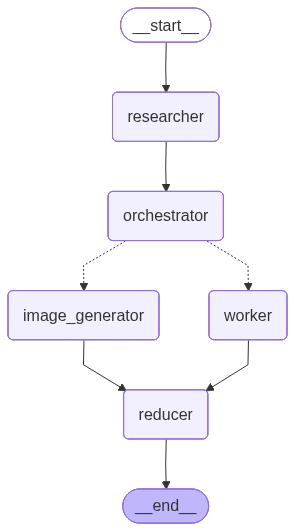

In [12]:
g = StateGraph(State)

# Add nodes
g.add_node("researcher",      researcher)
g.add_node("orchestrator",    orchestrator)
g.add_node("worker",          worker)
g.add_node("image_generator", image_generator)
g.add_node("reducer",         reducer)

# Linear: START → researcher → orchestrator
g.add_edge(START,          "researcher")
g.add_edge("researcher",   "orchestrator")

# Fan-out from orchestrator → workers + image_generator (all in parallel)
g.add_conditional_edges("orchestrator", fanout, ["worker", "image_generator"])

# All fan-out nodes → reducer → END
g.add_edge("worker",          "reducer")
g.add_edge("image_generator", "reducer")
g.add_edge("reducer",         END)

app = g.compile()
app

## Run

In [13]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": [], "images": []})

[Researcher] Done
[Orchestrator] 'Understanding Self-Attention: A Key Mechanism in Modern Neural Networks' — 4 sections
[Worker] Done: Introduction to Self-Attention
[Worker] Done: Modern Developments in Self-Attention
[Worker] Done: Advanced Concepts in Self-Attention
[Image Generator] 3 images queued
[Worker] Done: The Mechanics of Self-Attention
[Reducer] Blog saved → understanding_self-attention:_a_key_mechanism_in_modern_neural_networks.md


## Display the Final Blog

In [14]:
from IPython.display import Markdown
Markdown(out["final"])

# Understanding Self-Attention: A Key Mechanism in Modern Neural Networks

![self attention mechanism explanation](https://source.unsplash.com/featured/?self,attention,mechanism,explanation)

## Introduction to Self-Attention

Self-attention, a fundamental mechanism in modern neural networks, has revolutionized the way models process and understand sequential data. At its core, self-attention allows the model to weigh the importance of different elements in a sequence when making predictions. This capability is particularly crucial in tasks such as natural language processing (NLP) and image recognition, where understanding the context and relationships between elements is essential.

In models like BERT (Bidirectional Encoder Representations from Transformers), self-attention is pivotal. BERT uses self-attention to understand the context of words in a sentence bidirectionally, meaning it can consider both the left and right context of a word. This bidirectional processing is achieved through self-attention, which allows the model to capture the relationships between all words in the sentence, not just the ones preceding or following a given word. This capability is what makes BERT so effective in tasks such as text classification, question answering, and language generation.

Similarly, in vision transformers, self-attention is used to process and analyze images by understanding the relationships between different parts of the image. Unlike traditional convolutional neural networks (CNNs), which rely on local connections and fixed receptive fields, vision transformers use self-attention to capture global dependencies and relationships between different regions of the image. This approach enables the model to understand the context and structure of the image more effectively, making it particularly useful for tasks such as image classification and object detection.

The self-attention mechanism is built around three key components: the Query (Q), Key (K), and Value (V) vectors. These vectors are derived from the input sequence and are used to compute attention scores, which determine the importance of each element in the sequence. The attention score is calculated as the dot product of the query and key vectors, normalized by the square root of the key vector's dimension. This normalization helps to stabilize the gradients during training, making the model more robust and easier to train.

The attention weight, derived from the attention score, is then used to weigh the value vectors, which contain the actual information to be attended to. By combining the value vectors weighted by their respective attention weights, the model can generate a new representation that captures the most relevant information from the input sequence. This process is repeated multiple times, allowing the model to focus on different aspects of the input and build a more comprehensive understanding of the data.

In summary, self-attention is a powerful mechanism that enables neural networks to understand the context and relationships within sequential data. Its importance in models like BERT and vision transformers underscores its critical role in modern deep learning applications. By providing a mechanism for the model to weigh the importance of different elements in a sequence, self-attention enhances the model's ability to make accurate and contextually rich predictions.

![attention mechanism in transformers](https://source.unsplash.com/featured/?attention,mechanism,in,transformers)

## The Mechanics of Self-Attention

Self-attention is a fundamental mechanism in modern neural networks, particularly in models like transformers, which are widely used in natural language processing (NLP) and other sequence-based tasks. At its core, self-attention allows the model to weigh the importance of different elements in a sequence when making predictions. This section will delve into the detailed mechanics of computing attention scores and weights, and introduce the concept of scaled dot-product attention.

### Calculating Attention Scores

In self-attention, the model computes attention scores for each pair of elements in the input sequence. These scores are calculated using the dot product of the query (Q) and key (K) vectors. For each element in the sequence, the query vector is compared to the key vectors of all other elements. Mathematically, the attention score \( S_{ij} \) for element \( i \) and element \( j \) is given by:

\[ S_{ij} = \text{score}(Q_i, K_j) = \frac{Q_i^T K_j}{\sqrt{d_k}} \]

Here, \( Q_i \) and \( K_j \) are the query and key vectors, respectively, and \( d_k \) is the dimension of the key vector. The division by the square root of the key vector's dimension helps to stabilize the gradients during training, a concept known as scaling.

### Normalizing Attention Scores to Obtain Attention Weights

After computing the attention scores, the next step is to normalize these scores to obtain attention weights. This normalization ensures that the weights sum up to one, making them suitable for use as a probability distribution. The attention weights \( W_{ij} \) are calculated as:

\[ W_{ij} = \text{softmax}(S_{ij}) = \frac{\exp(S_{ij})}{\sum_{j'} \exp(S_{ij'})} \]

The softmax function ensures that the attention weights are normalized, making them interpretable as probabilities. This step is crucial as it determines the influence of each element in the sequence on the final output.

### Introducing Scaled Dot-Product Attention

While the basic self-attention mechanism is effective, it can be computationally expensive, especially for long sequences. To address this, the concept of scaled dot-product attention is introduced. Scaled dot-product attention is a specific implementation that scales the dot product by the square root of the key vector's dimension. This scaling helps to stabilize the gradients and improve the training dynamics, making the model more efficient and easier to train.

The scaled dot-product attention mechanism can be summarized as follows:

1. Compute the query, key, and value vectors for each element in the sequence.
2. Calculate the attention scores using the scaled dot product.
3. Normalize the attention scores to obtain attention weights.
4. Compute the weighted sum of the value vectors using the attention weights.

This process is repeated for each element in the sequence, allowing the model to focus on different parts of the input based on the computed attention weights.

By understanding the mechanics of self-attention, including the calculation of attention scores and weights, and the benefits of scaled dot-product attention, we can appreciate the power and flexibility of this mechanism in modern neural networks.

![self attention process visualization](https://source.unsplash.com/featured/?self,attention,process,visualization)

## Advanced Concepts in Self-Attention

Self-attention has revolutionized the field of neural networks, particularly in tasks involving sequential data. However, to fully leverage its capabilities, several advanced techniques have been developed. This section delves into multi-head attention, positional encoding, and the importance of self-attention in handling long-range dependencies.

### Multi-Head Attention

While the basic self-attention mechanism is powerful, it can sometimes struggle to capture the nuances of the input data. To address this, the concept of **multi-head attention** was introduced. Multi-head attention allows the model to focus on different aspects of the input sequence simultaneously, providing a more comprehensive understanding of the data.

In multi-head attention, the input sequence is projected into multiple subspaces using different linear transformations. Each of these subspaces is then processed by a separate self-attention mechanism, producing a set of attention scores and weights. These scores and weights are then combined to produce the final output. This parallel processing of the input sequence allows the model to capture different aspects of the data, leading to improved performance.

For example, in natural language processing (NLP), multi-head attention can help the model understand the context of words in a sentence from different perspectives. This is particularly useful in tasks like language translation, where the context of words can vary significantly depending on their position in the sentence.

### Positional Encoding

Self-attention mechanisms inherently treat all elements in the input sequence as equally important, regardless of their position. This can be a limitation, especially in tasks that require an understanding of the order of elements, such as natural language processing. To address this, **positional encoding** is used to add positional information to the input vectors.

Positional encoding is typically added to the input embeddings before the self-attention mechanism is applied. This encoding is designed to capture the relative positions of elements in the sequence. For example, in a sequence of words, the positional encoding can encode the fact that "the" is more likely to appear before "cat" than "dog" in a sentence.

The positional encoding is usually learned during training or can be fixed and learned during pre-training. This positional information helps the model to understand the order of elements, which is crucial for tasks like language understanding and text generation.

### Handling Long-Range Dependencies

One of the key challenges in self-attention is handling long-range dependencies in the input sequence. As the sequence length increases, the computational cost of self-attention grows quadratically, making it impractical for very long sequences. To address this, several techniques have been developed to handle long-range dependencies more efficiently.

**Reformer** is one such model that uses an efficient approximation of self-attention to handle longer sequences. Instead of computing attention scores for every pair of elements in the sequence, Reformer uses a technique called **linearized attention**, which approximates the attention mechanism using locality-sensitive hashing. This approach significantly reduces the computational complexity while maintaining the ability to capture long-range dependencies.

**Longformer** is another extension of BERT that specifically addresses long-range dependencies. It introduces a mechanism called **segment embedding** that allows the model to focus on different segments of the input sequence, reducing the computational burden while still capturing long-range dependencies.

**Linformer** takes a different approach by approximating the attention mechanism using a linear transformation. This reduces the computational complexity to linear time, making it feasible to handle very long sequences. However, this approximation can sometimes lead to a loss of accuracy, especially in tasks requiring precise long-range dependencies.

**Axial Transformers** are a variant of transformers that use self-attention along specific axes (e.g., rows and columns) to reduce computational complexity. This approach is particularly useful in tasks involving 2D data, such as image recognition, where the spatial relationships between elements are important.

### Conclusion

Advanced techniques like multi-head attention, positional encoding, and handling long-range dependencies have significantly expanded the capabilities of self-attention mechanisms. These techniques not only improve the performance of models but also make them more versatile and applicable to a wide range of tasks. As research continues to advance, we can expect even more sophisticated and efficient methods to emerge, further enhancing the power of self-attention in modern neural networks.

## Modern Developments in Self-Attention

Self-attention mechanisms have revolutionized the field of deep learning, particularly in natural language processing and image recognition. However, as the size and complexity of models have grown, so have the computational demands. To address these challenges, researchers have developed several innovative models and techniques that enhance the efficiency and effectiveness of self-attention. Let's explore some of these advancements.

### Reformer: Approximating Self-Attention for Long Sequences

The **Reformer** model addresses the issue of handling long sequences by approximating the self-attention mechanism. Traditional self-attention mechanisms have quadratic complexity, making them computationally expensive for long sequences. The Reformer uses a technique called **Locality-Sensitive Hashing (LSH)** to approximate the attention mechanism, reducing the computational complexity to linear. This makes it feasible to process longer sequences, such as full-length books or articles, which are crucial for tasks like long-range text understanding.

### Longformer: Handling Long-Range Dependencies

The **Longformer** model is an extension of BERT that specifically addresses long-range dependencies in text. While BERT uses self-attention to capture local dependencies, it struggles with long-range dependencies due to the quadratic complexity of the self-attention mechanism. The Longformer introduces a **segmented attention mechanism** that allows the model to focus on both local and global dependencies efficiently. This is achieved by applying self-attention only to certain segments of the sequence, while using a simpler mechanism for the rest. This approach significantly reduces the computational cost while maintaining the ability to capture long-range dependencies.

### Linformer: Reducing Computational Complexity

The **Linformer** model proposes a novel approach to self-attention by approximating the attention mechanism using a linear transformation. Instead of computing the full attention matrix, Linformer uses a learned projection matrix to map the input vectors into a lower-dimensional space. This reduces the computational complexity to linear, making it highly efficient for large-scale applications. The key idea is to approximate the attention mechanism using a linear transformation, which significantly reduces the number of computations required.

### Axial Transformers: Reducing Computational Complexity Along Specific Axes

The **Axial Transformers** model introduces a variant of the transformer architecture that uses self-attention along specific axes (e.g., rows and columns) to reduce computational complexity. This approach is particularly useful in tasks where the input can be naturally divided into two-dimensional structures, such as images. By applying self-attention along rows and columns separately, Axial Transformers can significantly reduce the number of attention computations while still capturing the necessary dependencies.

### Sparse Attention: Focusing on Relevant Parts

Sparse attention techniques reduce the number of attention computations by making the attention mechanism sparse, focusing only on relevant parts of the input. This is achieved by introducing a sparsity-inducing mechanism that encourages the model to pay attention only to a subset of the input elements. Sparse attention can be particularly useful in scenarios where the input is large but only a small portion is relevant to the task at hand. For example, in image recognition, the model might only need to focus on specific regions of the image, rather than considering the entire image.

These advancements in self-attention mechanisms not only enhance the efficiency and scalability of deep learning models but also open up new possibilities for handling complex and large-scale tasks. As research continues to evolve, we can expect even more innovative approaches to self-attention that will further push the boundaries of what is possible in deep learning.

